In [ ]:
# Marketing Mix Modeling (MMM) - Notebook Completo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# Config
plt.style.use('default')
sns.set()

In [3]:
# =====================================
# 2. LOAD DATA
# =====================================
df = pd.read_csv('data/advertising.csv')

print("Shape:", df.shape)
df.head()

Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


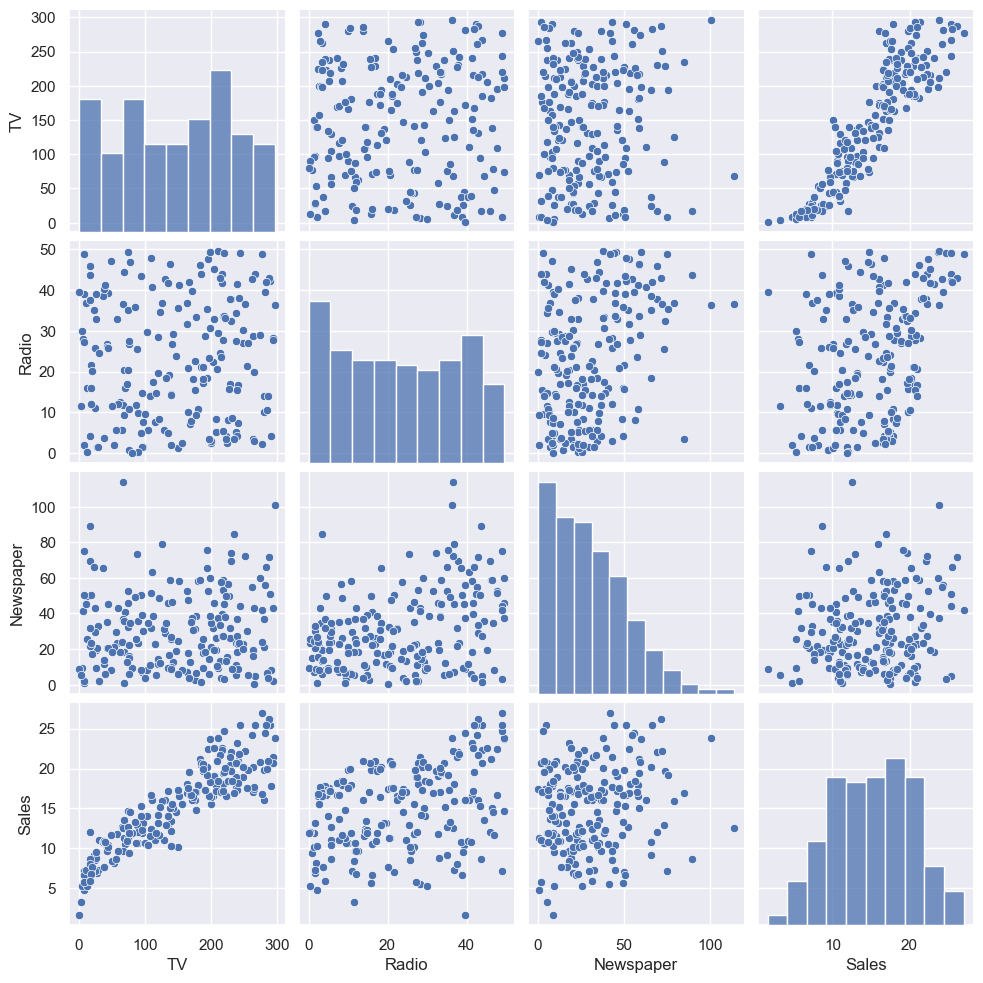

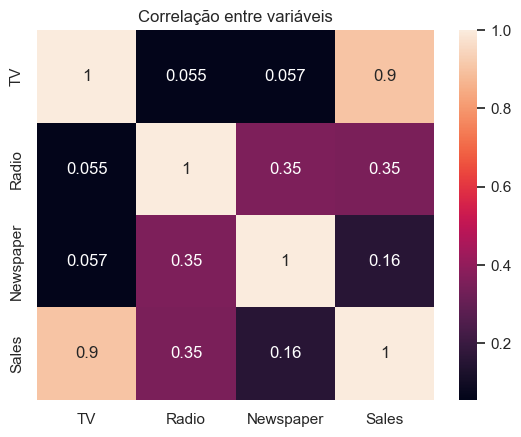

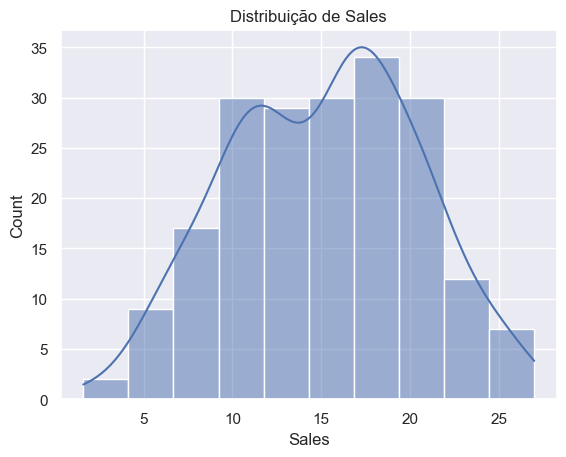

In [7]:
# =====================================
# 3. EDA - EXPLORATORY DATA ANALYSIS
# =====================================

# Estatísticas básicas
print(df.describe())

# Pairplot
sns.pairplot(df)
plt.show()

# Correlação
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title('Correlação entre variáveis')
plt.show()

# Distribuição de vendas
plt.figure()
sns.histplot(df['Sales'], kde=True)
plt.title('Distribuição de Sales')
plt.show()

In [9]:
# =====================================
# 4. MODELO BASE (SEM TRANSFORMAÇÕES)
# =====================================
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_const = sm.add_constant(X)
model_base = sm.OLS(y, X_const).fit()

print(model_base.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           8.13e-99
Time:                        16:04:44   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

In [11]:
# =====================================
# 5. ADSTOCK FUNCTION
# =====================================
def adstock(x, alpha=0.5): #efeito médio
    result = []
    for i, val in enumerate(x):
        if i == 0:
            result.append(val)
        else:
            result.append(val + alpha * result[i-1])
    return np.array(result)

# Aplicando adstock
df['TV_adstock'] = adstock(df['TV'], alpha=0.5)
df['Radio_adstock'] = adstock(df['Radio'], alpha=0.5)
df['Newspaper_adstock'] = adstock(df['Newspaper'], alpha=0.5)

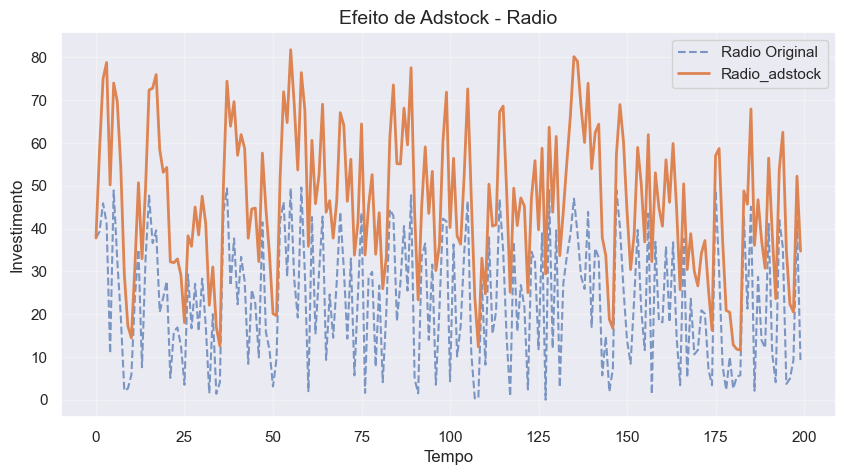

In [13]:
# =====================================
# 6. VISUALIZAÇÃO ADSTOCK
# =====================================
plt.figure(figsize=(10, 5))

plt.plot(df['Radio'], label='Radio Original', linestyle='--', alpha=0.7)
plt.plot(df['Radio_adstock'], label='Radio_adstock', linewidth=2)

plt.title('Efeito de Adstock - Radio', fontsize=14)
plt.xlabel('Tempo')
plt.ylabel('Investimento')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [15]:
print("""
ANÁLISE DO ADSTOCK:

- O gráfico mostra que o impacto do investimento em mídia não é imediato e isolado.
- Existe um efeito de memória, onde campanhas continuam influenciando vendas ao longo do tempo.
- Observa-se uma suavização da série, indicando persistência do efeito publicitário.
- Após picos de investimento, o impacto decai gradualmente (efeito de decay).
- Investimentos contínuos geram acúmulo de impacto, potencializando resultados.

INSIGHT DE NEGÓCIO:
Campanhas consistentes tendem a ser mais eficazes do que ações pontuais, devido ao efeito acumulativo da mídia.
""")


ANÁLISE DO ADSTOCK:

- O gráfico mostra que o impacto do investimento em mídia não é imediato e isolado.
- Existe um efeito de memória, onde campanhas continuam influenciando vendas ao longo do tempo.
- Observa-se uma suavização da série, indicando persistência do efeito publicitário.
- Após picos de investimento, o impacto decai gradualmente (efeito de decay).
- Investimentos contínuos geram acúmulo de impacto, potencializando resultados.

INSIGHT DE NEGÓCIO:
Campanhas consistentes tendem a ser mais eficazes do que ações pontuais, devido ao efeito acumulativo da mídia.



In [17]:
# =====================================
# 7. SATURAÇÃO
# =====================================

df['TV_sat'] = np.log1p(df['TV_adstock'])
df['Radio_sat'] = np.log1p(df['Radio_adstock'])
df['Newspaper_sat'] = np.log1p(df['Newspaper_adstock'])

In [19]:
# =====================================
# 8. MODELO MMM
# =====================================

X_mmm = df[['TV_sat', 'Radio_sat', 'Newspaper_sat']]
y = df['Sales']

X_mmm_const = sm.add_constant(X_mmm)

model_mmm = sm.OLS(y, X_mmm_const).fit()

print(model_mmm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.659
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     126.1
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           1.58e-45
Time:                        16:05:15   Log-Likelihood:                -508.70
No. Observations:                 200   AIC:                             1025.
Df Residuals:                     196   BIC:                             1039.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -54.2891      3.980    -13.640

In [31]:
# =====================================
# 10. INSIGHTS (ANÁLISE REAL)
# =====================================

print("\n========== MODELO MMM ==========\n")

coefs_mmm = model_mmm.params
pvalues_mmm = model_mmm.pvalues

for var in coefs_mmm.index:
    if var != 'const':
        print(f"Canal: {var}")
        print(f"Coeficiente: {coefs_mmm[var]:.4f}")
        print(f"P-valor: {pvalues_mmm[var]:.4f}")
        
        if pvalues_mmm[var] < 0.05:
            print("➡ Estatisticamente SIGNIFICATIVO")
        else:
            print("➡ NÃO significativo (pode ser descartado)")
        
        print("-" * 40)

print("========== MODELO BASE ==========\n")

coefs_base = model_base.params
pvalues_base = model_base.pvalues

for var in coefs_base.index:
    if var != 'const':
        print(f"Canal: {var}")
        print(f"Coeficiente: {coefs_base[var]:.4f}")
        print(f"P-valor: {pvalues_base[var]:.4f}")
        
        if pvalues_base[var] < 0.05:
             print("➡ Estatisticamente SIGNIFICATIVO")
        else:
            print("➡ NÃO significativo (pode ser descartado)")
        
        print("-" * 40)

# Canal mais relevante
canal_mais_importante = coefs_mmm.drop('const').abs().idxmax()

print(f"\n Canal com maior impacto: {canal_mais_importante}")

# Comparação com modelo base
print("\n Comparação de R²:")
print(f"Modelo Base: {model_base.rsquared:.4f}")
print(f"Modelo MMM: {model_mmm.rsquared:.4f}")

# Retorno decrescente (explicação)
print("\n Evidência de saturação:")
print("Transformações log indicam que aumentos de investimento geram retornos menores ao longo do tempo.")

print("\n============================================")


========== MODELO MMM ==========

Canal: TV_sat
Coeficiente: 10.7000
P-valor: 0.0000
➡ Estatisticamente SIGNIFICATIVO
----------------------------------------
Canal: Radio_sat
Coeficiente: 3.1181
P-valor: 0.0000
➡ Estatisticamente SIGNIFICATIVO
----------------------------------------
Canal: Newspaper_sat
Coeficiente: -0.5976
P-valor: 0.2561
➡ NÃO significativo (pode ser descartado)
----------------------------------------
========== MODELO BASE ==========

Canal: TV
Coeficiente: 0.0544
P-valor: 0.0000
➡ Estatisticamente SIGNIFICATIVO
----------------------------------------
Canal: Radio
Coeficiente: 0.1070
P-valor: 0.0000
➡ Estatisticamente SIGNIFICATIVO
----------------------------------------
Canal: Newspaper
Coeficiente: 0.0003
P-valor: 0.9538
➡ NÃO significativo (pode ser descartado)
----------------------------------------

 Canal com maior impacto: TV_sat

 Comparação de R²:
Modelo Base: 0.9026
Modelo MMM: 0.6588

 Evidência de saturação:
Transformações log indicam que aumentos

In [33]:
print("\n RECOMENDAÇÃO DE NEGÓCIO:")
print(f"- Priorizar investimento em {canal_mais_importante}")
print("- Reavaliar canais com baixa significância")
print("- Evitar aumento excessivo de budget devido à saturação")


 RECOMENDAÇÃO DE NEGÓCIO:
- Priorizar investimento em TV_sat
- Reavaliar canais com baixa significância
- Evitar aumento excessivo de budget devido à saturação


In [ ]:
'''
Identifiquei que rádio e TV são estatisticamente significativos, 
com destaque para o rádio como canal de maior impacto marginal. 
Além disso, observei que o modelo com adstock não trouxe ganho significativo de explicação, 
o que pode indicar que o dataset não captura bem efeitos de memória.
'''